In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [3]:
df = pd.read_csv('data\Mall_Customers.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\HP\AppData\Local\Temp\ipykernel_7756\207588857.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('data\Mall_Customers.csv')


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Annual Income vs Spending Score')

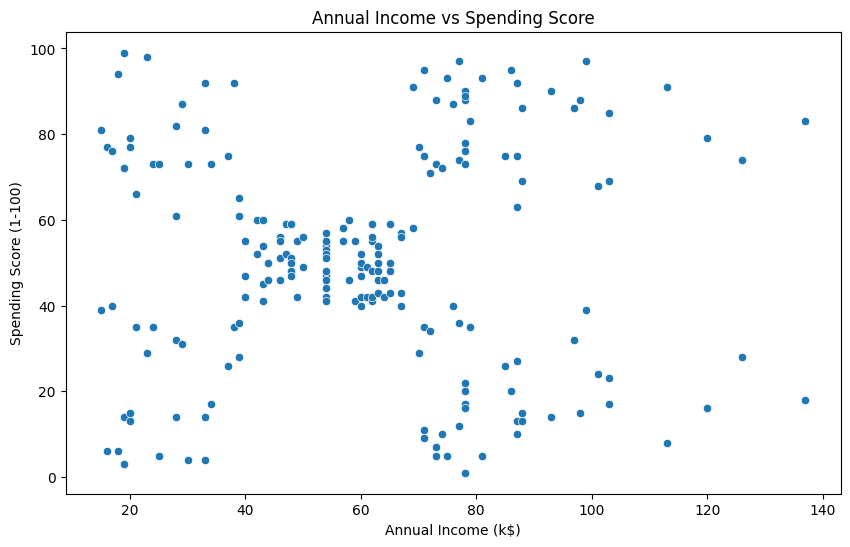

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Annual Income vs Spending Score')

Text(0.5, 1.0, 'Age Distribution')

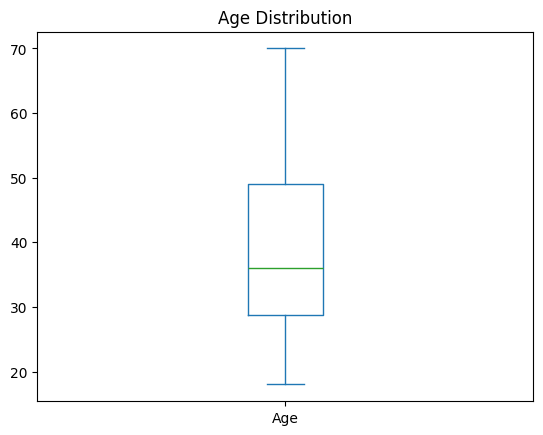

In [9]:
df['Age'].plot(kind='box')
plt.title('Age Distribution')

Text(0, 0.5, 'Count')

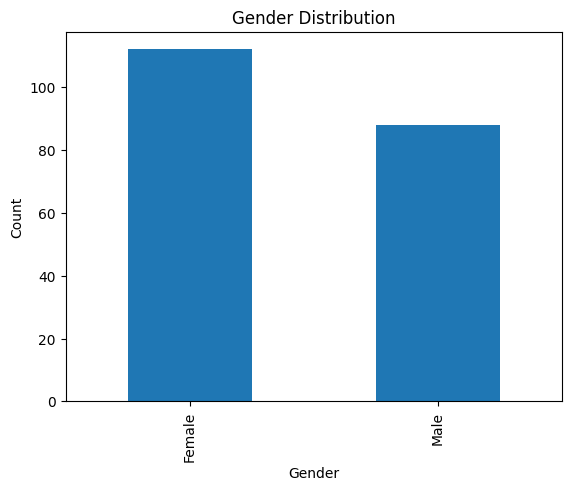

In [10]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

In [11]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [12]:
df.drop('CustomerID', axis=1, inplace=True)

In [13]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


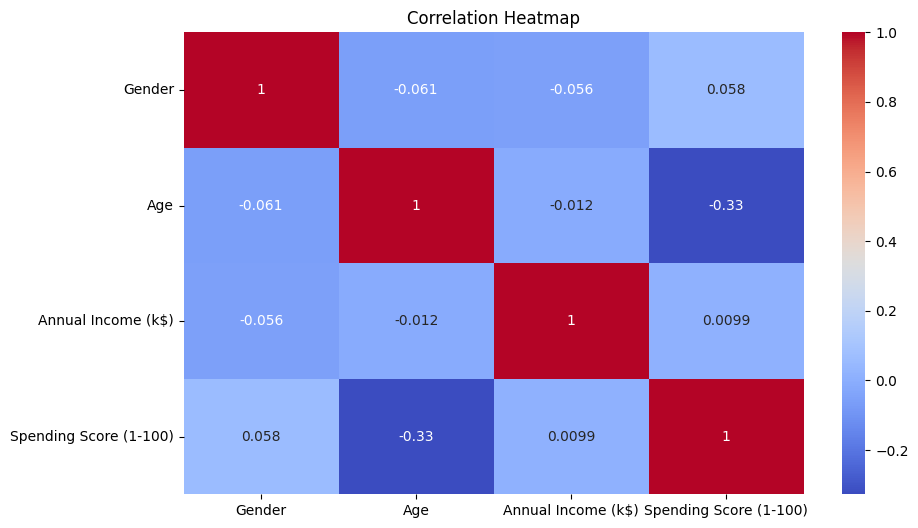

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [19]:
from model.k_means import KMeans

Đang tính toán WCSS cho các giá trị K...
Thuat toan da hoi tu tai lan lap thu: 2
Hoàn thành K = 1, WCSS = 800.00
Thuat toan da hoi tu tai lan lap thu: 11
Hoàn thành K = 2, WCSS = 588.80
Thuat toan da hoi tu tai lan lap thu: 10
Hoàn thành K = 3, WCSS = 502.37
Thuat toan da hoi tu tai lan lap thu: 7
Hoàn thành K = 4, WCSS = 403.37
Thuat toan da hoi tu tai lan lap thu: 11
Hoàn thành K = 5, WCSS = 325.68
Thuat toan da hoi tu tai lan lap thu: 8
Hoàn thành K = 6, WCSS = 309.12
Thuat toan da hoi tu tai lan lap thu: 11
Hoàn thành K = 7, WCSS = 249.36
Thuat toan da hoi tu tai lan lap thu: 11
Hoàn thành K = 8, WCSS = 226.61
Thuat toan da hoi tu tai lan lap thu: 6
Hoàn thành K = 9, WCSS = 188.99
Thuat toan da hoi tu tai lan lap thu: 10
Hoàn thành K = 10, WCSS = 186.09


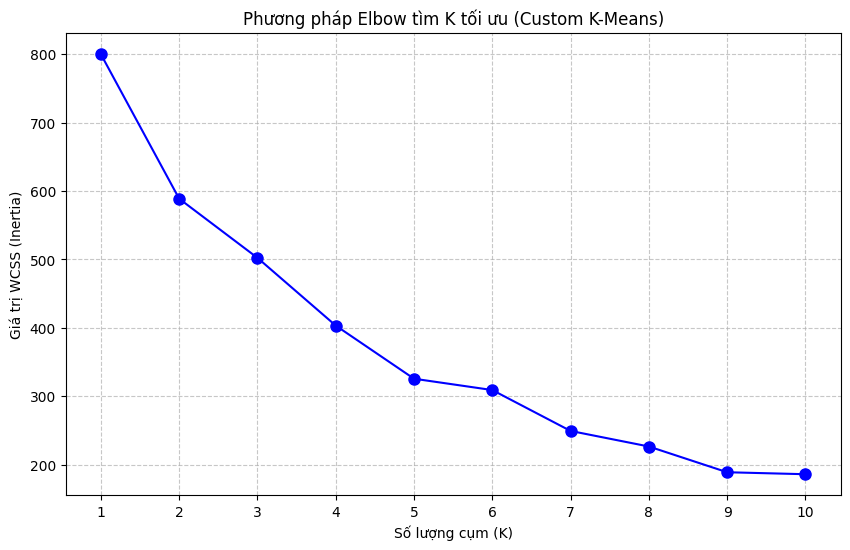

In [20]:
wcss_list = []
K_range = range(1, 11)
print("Đang tính toán WCSS cho các giá trị K...")
for k in K_range:
    model = KMeans(k=k, max_iters=100)
    
    model.fit(X_scaled)
    
    wcss = model.calculate_wcss()
    wcss_list.append(wcss)
    print(f"Hoàn thành K = {k}, WCSS = {wcss:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss_list, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Phương pháp Elbow tìm K tối ưu (Custom K-Means)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Giá trị WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [21]:
my_kmeans = KMeans(k=5, max_iters=300)


my_kmeans.fit(X_scaled)

custom_labels = my_kmeans.predict(X_scaled)

print(f'Centroids:\n{my_kmeans.centroids}')
print(f'Centroids as integers:\n{my_kmeans.centroids.astype(int)}')
print(f"WCSS (Inertia): {my_kmeans.calculate_wcss():.4f}")
print(f"Silhouette Score: {my_kmeans.calculate_silhouette_score():.4f}")
print(f"Davies-Bouldin Index: {my_kmeans.calculate_dbi():.4f}")
print(f"Calinski-Harabasz Index: {my_kmeans.calculate_calinski_harabasz():.4f}")

Thuat toan da hoi tu tai lan lap thu: 14
Centroids:
[[-0.45663301  0.21410396  1.05754765 -1.36651894]
 [ 0.88640526 -0.10222936  0.56172406  0.40027507]
 [ 0.88640526 -0.81746139 -0.89617693  0.18424503]
 [-0.32232919  1.31053949 -0.59815737 -0.39770532]
 [-1.12815215 -0.74015963  0.04751628  0.81127593]]
Centroids as integers:
[[ 0  0  1 -1]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  1  0  0]
 [-1  0  0  0]]
WCSS (Inertia): 351.3451
Silhouette Score: 0.2832
Davies-Bouldin Index: 1.2672
Calinski-Harabasz Index: 62.2520


In [24]:
df['Custom_Cluster'] = custom_labels

<Figure size 1200x1000 with 0 Axes>

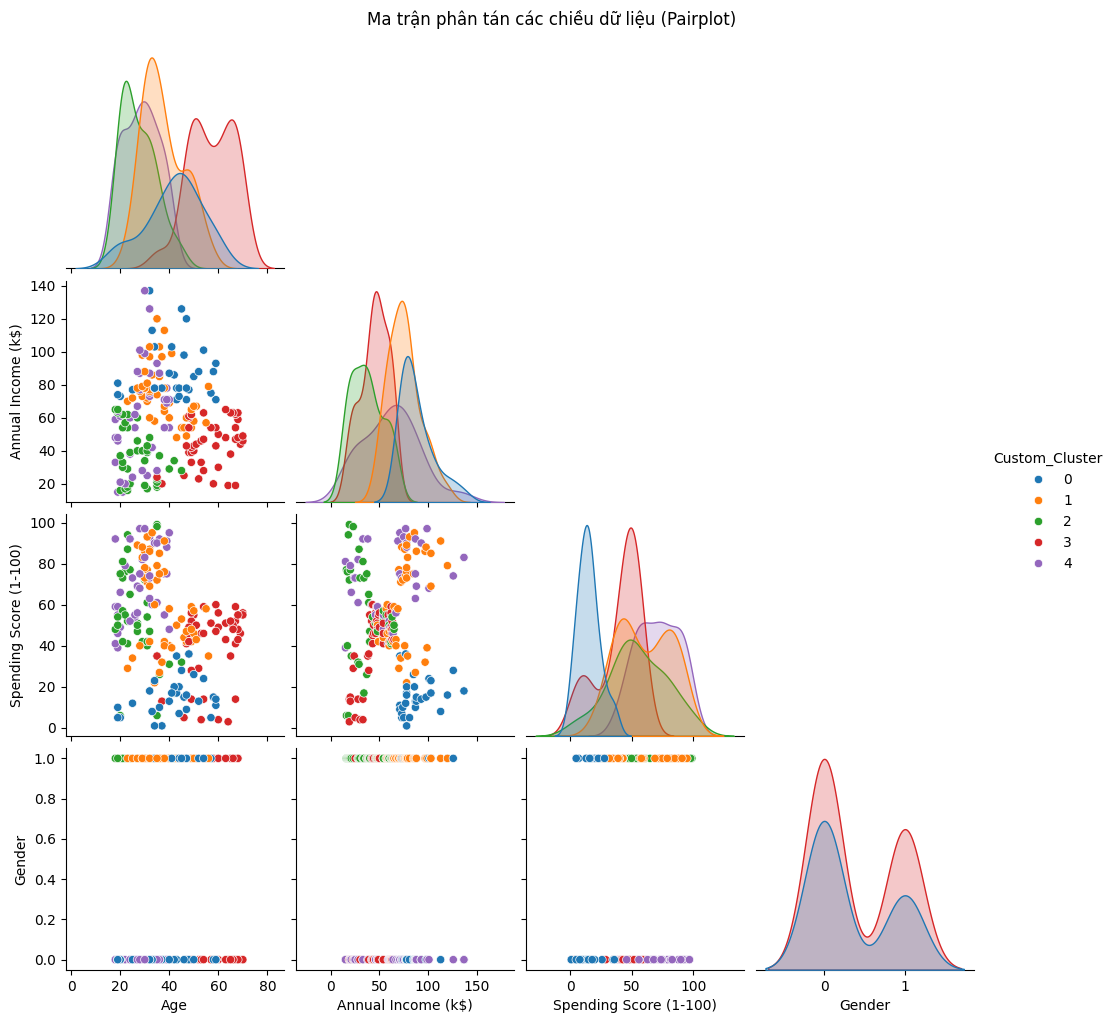

In [25]:
plt.figure(figsize=(12, 10))
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender', 'Custom_Cluster']], 
             hue='Custom_Cluster', 
             palette='tab10', 
             corner=True)
plt.suptitle('Ma trận phân tán các chiều dữ liệu (Pairplot)', y=1.02)
plt.show()

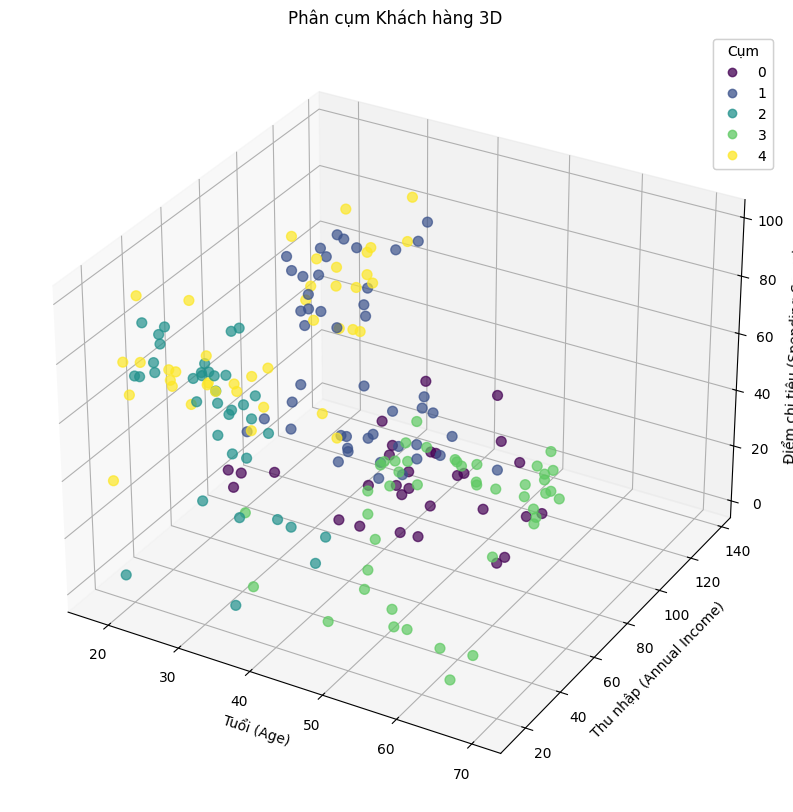

In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Age'], 
                     df['Annual Income (k$)'], 
                     df['Spending Score (1-100)'], 
                     c=df['Custom_Cluster'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.7)

ax.set_title('Phân cụm Khách hàng 3D')
ax.set_xlabel('Tuổi (Age)')
ax.set_ylabel('Thu nhập (Annual Income)')
ax.set_zlabel('Điểm chi tiêu (Spending Score)')

legend = ax.legend(*scatter.legend_elements(), title="Cụm")
ax.add_artist(legend)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_kmeans_clusters(X, labels, centroids, feature_x_idx=0, feature_y_idx=1, title="Kết quả Phân cụm K-Means"):
    """
    Hàm trực quan hóa 2 chiều kết quả phân cụm (Độc lập với Model).
    
    Tham số:
    - X: Mảng dữ liệu gốc (numpy array)
    - labels: Mảng chứa nhãn cụm của từng điểm dữ liệu
    - centroids: Mảng chứa tọa độ của các tâm cụm
    - feature_x_idx: Chỉ số cột của đặc trưng vẽ trên trục X
    - feature_y_idx: Chỉ số cột của đặc trưng vẽ trên trục Y
    - title: Tiêu đề của biểu đồ
    """
    k = len(centroids)
    
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'orange']
    
    plt.figure(figsize=(10, 6))
    
  
    for i in range(k):
        cluster_points = X[labels == i]
        
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:, feature_x_idx], 
                        cluster_points[:, feature_y_idx], 
                        s=50, 
                        c=colors[i % len(colors)], 
                        label=f'Cụm {i}', 
                        alpha=0.6)
    
    plt.scatter(centroids[:, feature_x_idx], 
                centroids[:, feature_y_idx], 
                s=250, 
                c='red', 
                marker='X', 
                label='Tâm cụm (Centroids)')
    
    plt.title(title)
    plt.xlabel(f'Feature Index: {feature_x_idx}')
    plt.ylabel(f'Feature Index: {feature_y_idx}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

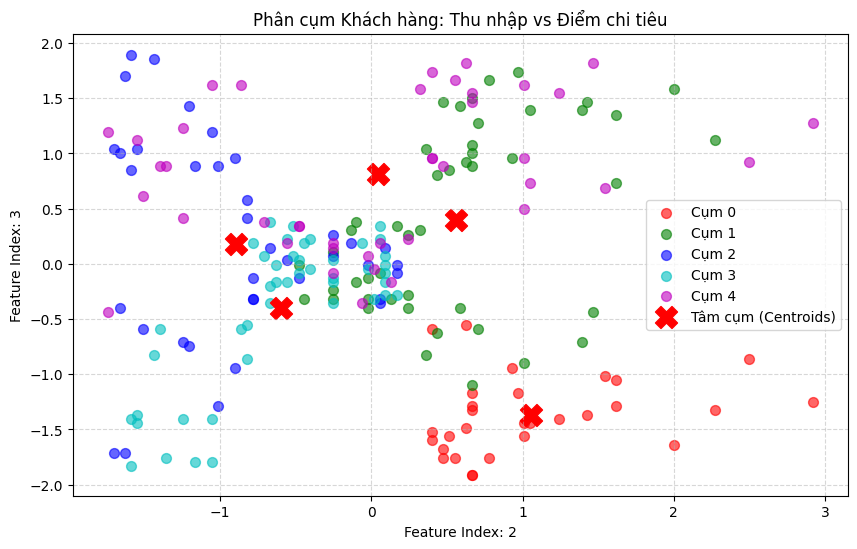

In [31]:
custom_centroids = my_kmeans.centroids

plot_kmeans_clusters(
    X=X_scaled, 
    labels=custom_labels, 
    centroids=custom_centroids, 
    feature_x_idx=2, 
    feature_y_idx=3, 
    title="Phân cụm Khách hàng: Thu nhập vs Điểm chi tiêu"
)